In [ ]:
import snowflake.connector
con = snowflake.connector.connect(
    user = 'adhidhya',
		password='Adhidhya_31428',
		account = 'KQUUHOO-UP24252',
		database='PRAT',
		schema = 'PUBLIC',
		warehouse = 'COMPUTE_WH',
);

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
query="select * from prat"
df=pd.read_sql(query,con)
con.close()
df

/tmp/ipykernel_575/4287543478.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,con)


,LONG_HAIR,FOREHEAD_WIDTH_CM,FOREHEAD_HEIGHT_CM,NOSE_WIDE,NOSE_LONG,LIPS_THIN,DISTANCE_NOSE_TO_LIP_LONG,GENDER
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [ ]:


df.shape

(5001, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   LONG_HAIR                  5001 non-null   int64  
 1   FOREHEAD_WIDTH_CM          5001 non-null   float64
 2   FOREHEAD_HEIGHT_CM         5001 non-null   float64
 3   NOSE_WIDE                  5001 non-null   int64  
 4   NOSE_LONG                  5001 non-null   int64  
 5   LIPS_THIN                  5001 non-null   int64  
 6   DISTANCE_NOSE_TO_LIP_LONG  5001 non-null   int64  
 7   GENDER                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [ ]:
df.describe()
import seaborn as sns

<Axes: >

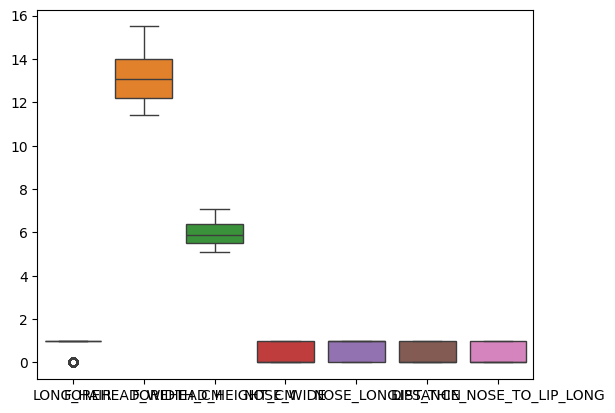

In [ ]:
sns.boxplot(df)

In [ ]:
q1=df['FOREHEAD_WIDTH_CM'].quantile(0.25)
q3=df['FOREHEAD_WIDTH_CM'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
df[(df['FOREHEAD_WIDTH_CM']<lower) | (df['FOREHEAD_WIDTH_CM']>upper)]

,LONG_HAIR,FOREHEAD_WIDTH_CM,FOREHEAD_HEIGHT_CM,NOSE_WIDE,NOSE_LONG,LIPS_THIN,DISTANCE_NOSE_TO_LIP_LONG,GENDER


In [ ]:

q1=df['FOREHEAD_HEIGHT_CM'].quantile(0.25)
q3=df['FOREHEAD_HEIGHT_CM'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
df[(df['FOREHEAD_HEIGHT_CM']<lower) | (df['FOREHEAD_HEIGHT_CM']>upper)]

,LONG_HAIR,FOREHEAD_WIDTH_CM,FOREHEAD_HEIGHT_CM,NOSE_WIDE,NOSE_LONG,LIPS_THIN,DISTANCE_NOSE_TO_LIP_LONG,GENDER


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
x=df.drop(['GENDER'],axis=1)
y=df['GENDER']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
tree=DecisionTreeClassifier()
tree.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=tree.predict(x_test)

In [ ]:
print('accuracy:',accuracy_score(y_pred,y_test))

accuracy: 0.954045954045954
